Problem statement Assignment – AIE4290


Let us consider that we have five tasks whose duration in days are defined by the
following functions:

f(x) =

            x + 4 ∗ i if 1 ≤ x ≤ 10
            x + 2 ∗ i if 11 ≤ x ≤ 20
            x + i if 21 ≤ x

where x is your class serial number, and i is the task number. You need to follow that
function to which your serial number belongs to.


Show the task completion percentage as twice the duration of the task. The current
day marker can be taken as half of the longest task duration. Each subsequent task
must start at an interval of 3 days from its predecessor.


Write a Python program to plot Gantt chart for the above problem. You need to show
every calculation in your program, and proper annotation (if any) must also be used
on the plot.

Note: You must submit your python code file and the Gantt plot as well.

In [ ]:
import matplotlib.pyplot as plt

# INPUT: serial number
x = 12     

# Function to compute task duration
def task_duration(x, i):
    if 1 <= x <= 10:
        return x + 4*i
    elif 11 <= x <= 20:
        return x + 2*i
    else:
        return x + i

In [7]:
# Calculate task durations for 5 tasks
durations = []
for i in range(1, 6):
    d = task_duration(x, i)
    durations.append(d)
    print(f"Task {i} duration = f(x) = {d}")

print("\nDurations list:", durations)

Task 1 duration = f(x) = 14
Task 2 duration = f(x) = 16
Task 3 duration = f(x) = 18
Task 4 duration = f(x) = 20
Task 5 duration = f(x) = 22

Durations list: [14, 16, 18, 20, 22]


In [8]:
# Task completion percentage = 2 × duration
completion = [2 * d for d in durations]
print("\nTask completion percentages:", completion)


Task completion percentages: [28, 32, 36, 40, 44]


In [9]:
# Start times: each task starts 3 days after the previous one
start_times = []
current_start = 0
for d in durations:
    start_times.append(current_start)
    current_start += d + 3      # finish time + 3-day gap

print("\nStart times:", start_times)


Start times: [0, 17, 36, 57, 80]


In [10]:
# End times
end_times = [start_times[i] + durations[i] for i in range(5)]
print("End times:", end_times)


End times: [14, 33, 54, 77, 102]


In [11]:
# Current day marker = half of longest duration
longest = max(durations)
current_day = longest / 2
print(f"\nCurrent Day Marker = {current_day}")


Current Day Marker = 11.0


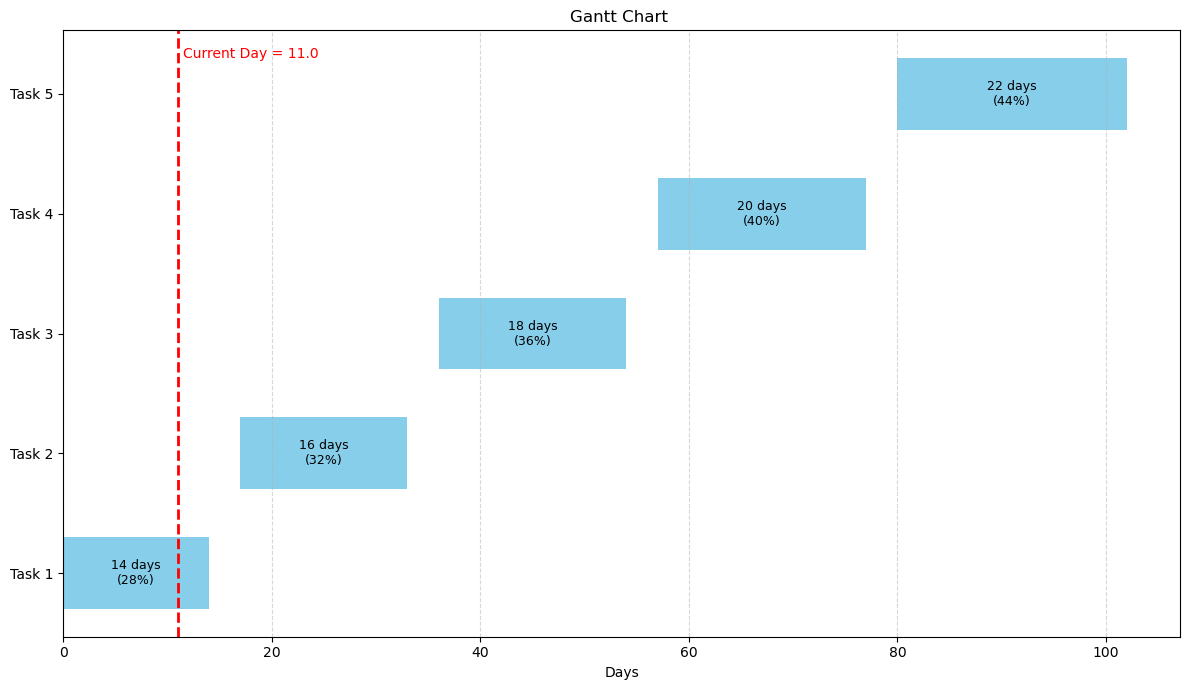

In [17]:
# Gantt Chart Plot

fig, ax = plt.subplots(figsize=(12, 7))

task_labels = [f"Task {i}" for i in range(1, 6)]

for i in range(5):
    ax.barh(task_labels[i],
            durations[i],
            left=start_times[i],
            height=0.6,
            color='skyblue')

    # Annotate duration and completion %
    ax.text(start_times[i] + durations[i]/2,
            i,
            f"{durations[i]} days\n({completion[i]}%)",
            va='center', ha='center', fontsize=9)

# Current day marker line
ax.axvline(current_day, color='red', linestyle='--', linewidth=2)
ax.text(current_day + 0.5, 4.3, f"Current Day = {current_day}", color='red')

# Title and labels
ax.set_xlabel("Days")
ax.set_title("Gantt Chart ")
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
